## Data Description

The code repo can be found here: https://github.com/MendeBadra/trustworthy_ai_course.

This analysis combines official datasets from Mongolia’s NSO (1212.mn) to study housing affordability in **Ulaanbaatar**.

### Sources
- **Housing price index (DT_NSO_0300_00V3)**: apartment price per 1 m², by district and quarter (historical period).
- **Housing price index (DT_NSO_0300_00V4)**: apartment price per 1 m², by district and month (recent period), split by new vs. old apartments.
- **Population livelihood (DT_NSO_1900_001V3)**: average monthly household income by year.

### Variable interpretation
- **District / Дүүрэг**: the 6 central districts of **Ulaanbaatar** (`Bayangol`, `Bayanzurkh`, `Songinohairkhan`, `Sukhbaatar`, `Khan-Uul`, `Chingeltei`).  
  - `Average / Дундаж` is a city-level aggregate, not a district.
- **Type / Үзүүлэлт**: apartment category in V4:
  - `new` = new apartment average price
  - `second` (labeled `sechand` in code) = old apartment average price
- **Month / Сар**: monthly timestamp (`YYYY-MM`) for V4.
- **Season / Улирал**: quarter label for V3 (parsed into `Year` + `Quarter`).
- **PricePerSquareMeter(Million Tug)**: price per 1 m² in **million MNT** (V4).
- **PricePerSquareMeter(Thousand Tug)**: price per 1 m² in **thousand MNT** (V3).
- **Income / NetIncome_MNT**: average **monthly household income** in MNT (annual series).
- **sqm_affordable**: affordability indicator:

$$
\mathrm{sqm\_affordable}
=
\frac{\mathrm{monthly\ net\ income}}{\mathrm{price\ per\ m}^2}
$$

Interpreted as how many square meters can be bought with one month’s income.

### Notes
- Income is annual and city-level, so district differences in affordability are driven mainly by district-level price differences.
- The two housing datasets have different original frequencies, but both are analyzed at quarter level for comparison.

In [51]:
import requests
import json
from itertools import product

import numpy as np
import pandas as pd


In [86]:
# Real estate prices 2022-2026
def fetch_json_stat_dataset(url, query_fp):
    with open(query_fp, "r", encoding="utf-8") as f:
        query = json.load(f)

    response = requests.post(url, json=query, timeout=30)
    response.raise_for_status()
    return response.json()

url = "https://data.1212.mn:443/api/v1/mn/NSO/Economy, environment/Housing price index/DT_NSO_0300_00V4.px"
query_fp = "assets/1212_realestate_2022_2026_query.json"
data_realestate_price_2022_2026 = fetch_json_stat_dataset(
    url, query_fp
)
# data_realestate_price_2022_2026

In [87]:
# Real estate price 2007-2021
url = "https://data.1212.mn:443/api/v1/mn/NSO/Economy, environment/Housing price index/DT_NSO_0300_00V3.px"
query_fp = "assets/1212_realestate_2007_2021_query.json"
data_realestate_price_2007_2022 = fetch_json_stat_dataset(
    url, query_fp
)
# data_realestate_price_2007_2022

In [88]:
# Population livelihood
url = "https://data.1212.mn:443/api/v1/mn/NSO/Regional development/Population livelihood/DT_NSO_1900_001V3.px"

query_fp = "assets/1212_livelihood_query.json"

data_net_income = fetch_json_stat_dataset(url, query_fp)
# print(data_net_income)


In [113]:
# Realestate
# Let's call 2022-2026 
# data_realestate_price_2022_2026  # your dict

def labels_in_order(data, dim_name):
    """Helper function for `build_realestate_price_df"""
    cat = data["dimension"][dim_name]["category"]
    idx = cat["index"]   # code -> position
    lbl = cat["label"]   # code -> text
    return [lbl[code] for code, pos in sorted(idx.items(), key=lambda x: x[1])]


def build_realestate_price_df(data, unit_of_money = "Million Tug"):
    """Build the realestate dataframe
    Params:
    data - data dictionary
    unit_of_money - one of "Million Tug" and "Thousand Tug"
    """
# 1) Extract labels in correct positional order for each dimension
    dims = data["id"]  # ['Үзүүлэлт', 'Дүүрэг', 'Сар']
    vals_by_dim = [labels_in_order(data, dim) for dim in dims]

    # 2) Build long dataframe (all combinations + value)
    rows = list(product(*vals_by_dim))
    df_price_long = pd.DataFrame(rows, columns=dims)
    df_price_long[f"PricePerSquareMeter({unit_of_money})"] = data["value"]  # unit is million MNT

    # # Optional: make month a datetime
    # df_price_long["Сар"] = pd.to_datetime(df_price_long["Сар"])
    # df_price_long.sort_values("Сар").reset_index(drop=True)
    return df_price_long

df_realestate_price_2022_2026 = build_realestate_price_df(data_realestate_price_2022_2026, unit_of_money="Million Tug")

df_realestate_price_2007_2022 = build_realestate_price_df(data_realestate_price_2007_2022, unit_of_money="Thousand Tug")

In [114]:
# Using English column and value names
df_realestate_price_2022_2026.rename(columns={
    "Үзүүлэлт": "Type", # New or used, which is only available for 2022-2026 data
    "Дүүрэг": "District",
    "Сар": "Month"
}, inplace=True)

# print(df_realestate_price_2022_2026["Type"].unique())
# print("This means we have used, and new")

# print(df_realestate_price_2022_2026["District"].unique())

district_translation = {
        "Баянгол": "Bayangol",
        "Баянзүрх": "Bayanzurkh",
        "Сонгинохайрхан": "Songinohairhan",
        "Сүхбаатар": "Sukhbaatar",
        "Хан-Уул": "Khan-Uul",
        "Чингэлтэй": "Chingeltei",
        "Дундаж": "Average", # NOTE: There is the average here.
    }
type_translation = {
        "Шинэ орон сууцны дундаж үнэ": "new",
        "Хуучин орон сууцны дундаж үнэ": "sechand"
    }

df_realestate_price_2022_2026.replace({
    "Type": type_translation,
    "District": district_translation   
}, inplace=True)

df_realestate_price_2007_2022.rename(columns={
    "Дүүрэг": "District",
    "Улирал": "Season",
}, inplace=True)

df_realestate_price_2007_2022.replace({
    "District": district_translation,
}, inplace=True);
# print(df_realestate_price_2007_2022["District"].unique())
print(df_realestate_price_2007_2022.head())

print(df_realestate_price_2022_2026.head())

     District   Season  PricePerSquareMeter(Thousand Tug)
0  Bayanzurkh  2021-04                             1782.0
1  Bayanzurkh  2021-03                             1761.3
2  Bayanzurkh  2021-02                             1750.9
3  Bayanzurkh  2021-01                             1748.7
4  Bayanzurkh  2020-04                             1750.5
  Type  District    Month  PricePerSquareMeter(Million Tug)
0  new  Bayangol  2026-03                              4.59
1  new  Bayangol  2026-02                              4.46
2  new  Bayangol  2026-01                              4.58
3  new  Bayangol  2025-12                              4.59
4  new  Bayangol  2025-11                              4.57


In [117]:
# Income
year_index_label_dict = data_net_income["dimension"]["Он"]["category"]
# maybe not needed but code -> position , which in this case is 0 -> 0 etc.
year_index = year_index_label_dict["index"] 
# position -> year 
year_label = year_index_label_dict["label"]

# years in same order as the "value" field in data_net_income
years = [
    year_label[code]
    for code, pos in sorted(year_index.items(), key=lambda x: x[1])
]

df_net_income = pd.DataFrame({
    "Year": pd.to_numeric(years, errors="coerce"),
    "Income": data_net_income["value"]
})
# sort the array by "On" 
df_net_income = df_net_income.sort_values("Year").reset_index(drop=True)
df_net_income.head()

,Year,Income
0,2007,290796
1,2008,425328
2,2009,489157
3,2010,529248
4,2011,705031


## Part 1 — Analytical Questions
**Q1: How did the ratio of used to new home sales change by region over time?**

Unfortunately, I can't seem to find the sales data.

**Q2: In which region and at what time could one purchase how many square meters of a new apartment with a single
month's average net wage?**

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

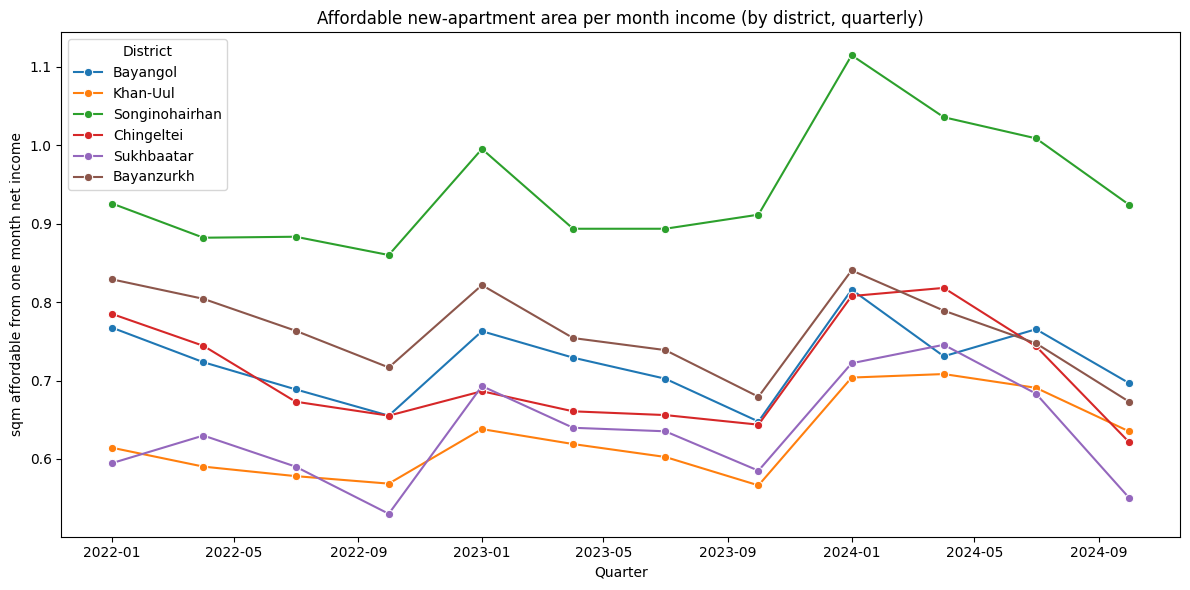

,District,Quarter,PricePerSquareMeter(Million Tug),Year,NetIncome_MNT,PricePerSquareMeter_MNT,sqm_affordable,QuarterStart
0,Bayangol,2022Q1,2.690000,2022,2063887.0,2.690000e+06,0.767244,2022-01-01
1,Bayangol,2022Q2,2.853333,2022,2063887.0,2.853333e+06,0.723325,2022-04-01
2,Bayangol,2022Q3,2.996667,2022,2063887.0,2.996667e+06,0.688728,2022-07-01
3,Bayangol,2022Q4,3.150000,2022,2063887.0,3.150000e+06,0.655202,2022-10-01
4,Bayangol,2023Q1,3.170000,2023,2418249.0,3.170000e+06,0.762855,2023-01-01


In [ ]:
# 1) Keep new apartments only, build quarter
df_new_price = df_realestate_price_2022_2026[
    df_realestate_price_2022_2026["Type"] == "new"
].copy()

df_new_price["Month"] = pd.to_datetime(df_new_price["Month"])
df_new_price["Quarter"] = df_new_price["Month"].dt.to_period("Q")

# Optional: drop overall average row to keep only districts
df_new_price = df_new_price[df_new_price["District"] != "Average"]

# 2) Quarterly avg price per sqm (million MNT) by district
df_q_price = (
    df_new_price
    .groupby(["District", "Quarter"], as_index=False)["PricePerSquareMeter(Million Tug)"]
    .mean()
)

# 3) Expand annual income to quarter via Year
df_q_price["Year"] = df_q_price["Quarter"].dt.year
df_income = df_net_income.rename(columns={"Income": "NetIncome_MNT"}).copy()

df_afford = df_q_price.merge(df_income[["Year", "NetIncome_MNT"]], on="Year", how="left")

# 4) sqm affordable with one month income
# price is million MNT per sqm -> convert to MNT per sqm
df_afford["PricePerSquareMeter_MNT"] = df_afford["PricePerSquareMeter(Million Tug)"] * 1_000_000
df_afford["sqm_affordable"] = df_afford["NetIncome_MNT"] / df_afford["PricePerSquareMeter_MNT"]

# 5) Plot over time by district (region)
df_afford["QuarterStart"] = df_afford["Quarter"].dt.start_time

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_afford.sort_values("QuarterStart"),
    x="QuarterStart",
    y="sqm_affordable",
    hue="District",
    marker="o"
)
plt.title("Affordable new-apartment area per month income (by district, quarterly)")
plt.xlabel("Quarter")
plt.ylabel("sqm affordable from one month net income")
plt.tight_layout()
plt.show()

df_afford.head()

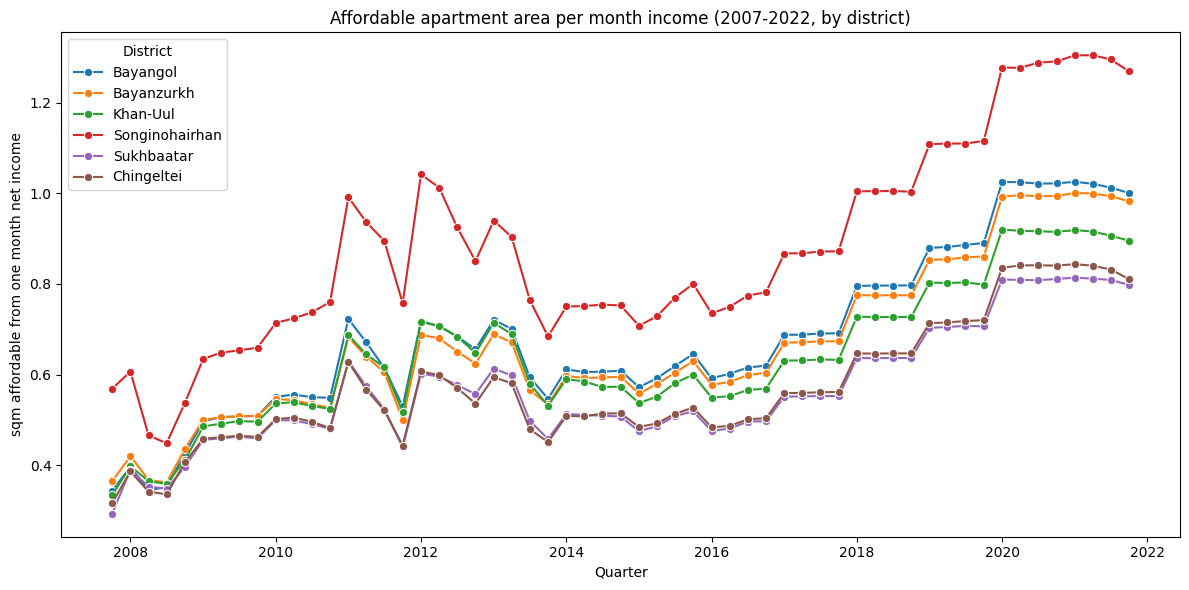

,District,Quarter,PricePerSquareMeter(Thousand Tug),Year,NetIncome_MNT,PricePerSquareMeter_MNT,sqm_affordable,QuarterStart
0,Bayangol,2007Q4,845.0,2007,290796,845000.0,0.344137,2007-10-01
1,Bayangol,2008Q1,1072.5,2008,425328,1072500.0,0.396576,2008-01-01
2,Bayangol,2008Q2,1232.6,2008,425328,1232600.0,0.345066,2008-04-01
3,Bayangol,2008Q3,1208.3,2008,425328,1208300.0,0.352005,2008-07-01
4,Bayangol,2008Q4,998.9,2008,425328,998900.0,0.425796,2008-10-01


In [119]:
# ---- Affordability for 2007-2022 data ----
df_old_price = df_realestate_price_2007_2022.copy()

# Optional: keep district-only rows
if "District" in df_old_price.columns:
    df_old_price = df_old_price[df_old_price["District"] != "Average"]

# Parse Year + Quarter from Season (supports both Roman and numeric quarter markers)
season_str = df_old_price["Season"].astype(str).str.strip()
parsed = season_str.str.extract(r'(?P<Year>\d{4}).*?(?P<Q>IV|III|II|I|[1-4])')

roman_to_num = {"I": "1", "II": "2", "III": "3", "IV": "4"}
q_num = parsed["Q"].replace(roman_to_num)

df_old_price["Year"] = pd.to_numeric(parsed["Year"], errors="coerce")
df_old_price["Quarter"] = pd.PeriodIndex(
    parsed["Year"].astype(str) + "Q" + q_num.astype(str),
    freq="Q"
)

# Quarterly avg price per sqm (thousand MNT) by district
df_q_price_old = (
    df_old_price
    .dropna(subset=["Year", "Quarter"])
    .groupby(["District", "Quarter"], as_index=False)["PricePerSquareMeter(Thousand Tug)"]
    .mean()
)

# Merge annual income (MNT)
df_income = df_net_income.rename(columns={"Income": "NetIncome_MNT"}).copy()
df_q_price_old["Year"] = df_q_price_old["Quarter"].dt.year

df_afford_old = df_q_price_old.merge(
    df_income[["Year", "NetIncome_MNT"]],
    on="Year",
    how="left"
)

# sqm affordable = monthly net income / price per sqm
# old prices are in thousand MNT -> convert to MNT
df_afford_old["PricePerSquareMeter_MNT"] = df_afford_old["PricePerSquareMeter(Thousand Tug)"] * 1_000
df_afford_old["sqm_affordable"] = df_afford_old["NetIncome_MNT"] / df_afford_old["PricePerSquareMeter_MNT"]

# Plot
df_afford_old["QuarterStart"] = df_afford_old["Quarter"].dt.start_time

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_afford_old.sort_values("QuarterStart"),
    x="QuarterStart",
    y="sqm_affordable",
    hue="District",
    marker="o"
)
plt.title("Affordable apartment area per month income (2007-2022, by district)")
plt.xlabel("Quarter")
plt.ylabel("sqm affordable from one month net income")
plt.tight_layout()
plt.show()

df_afford_old.head()

From above two charts, you could see that district `Songinohairhan` consistently been affordable for average household for many years. This could be due to the fact that the price of land is cheap there.

Let's see if the two trends are combined:

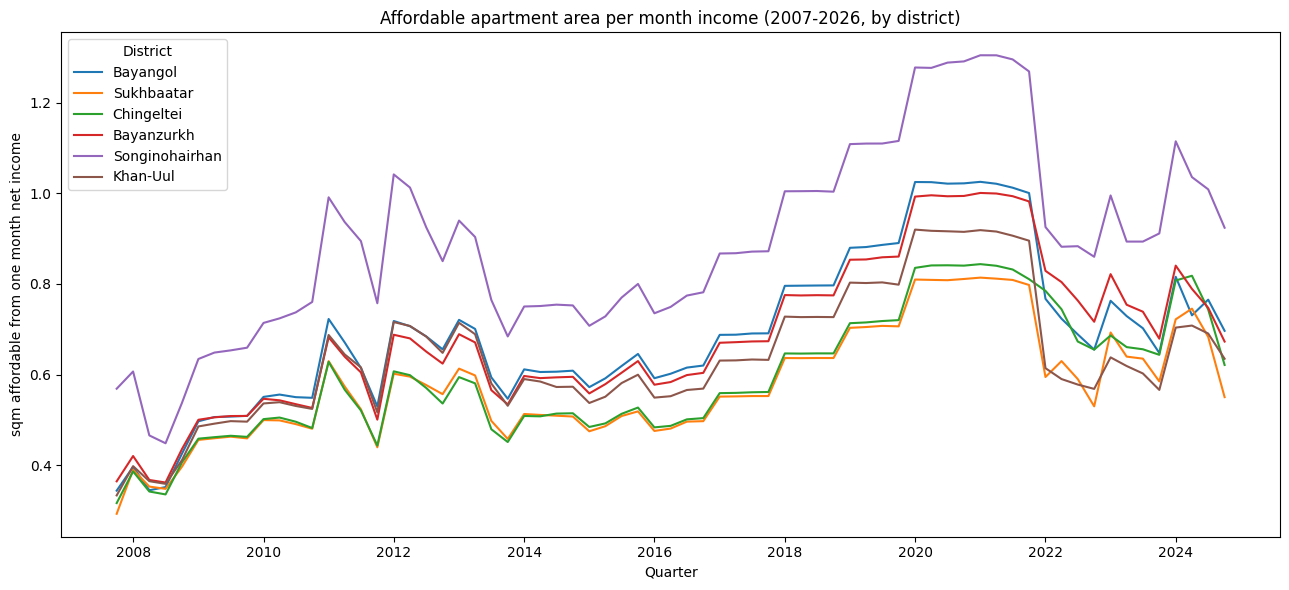

In [120]:
# Keep only needed columns + source tag
new_part = df_afford[["District", "Quarter", "sqm_affordable"]].copy()
new_part["Source"] = "2022_2026"

old_part = df_afford_old[["District", "Quarter", "sqm_affordable"]].copy()
old_part["Source"] = "2007_2022"

# Combine
df_afford_all = pd.concat([old_part, new_part], ignore_index=True)

# Optional: resolve overlap (2022) by preferring newer dataset when same District+Quarter exists
source_priority = {"2007_2022": 0, "2022_2026": 1}
df_afford_all["priority"] = df_afford_all["Source"].map(source_priority)

df_afford_all = (
    df_afford_all
    .sort_values(["District", "Quarter", "priority"])
    .drop_duplicates(subset=["District", "Quarter"], keep="last")
    .drop(columns="priority")
)

df_afford_all["QuarterStart"] = df_afford_all["Quarter"].dt.start_time

# Plot
plt.figure(figsize=(13, 6))
sns.lineplot(
    data=df_afford_all.sort_values("QuarterStart"),
    x="QuarterStart",
    y="sqm_affordable",
    hue="District"
)
plt.title("Affordable apartment area per month income (2007-2026, by district)")
plt.xlabel("Quarter")
plt.ylabel("sqm affordable from one month net income")
plt.tight_layout()
plt.show()

Combined, we can see a general trend of housing prices becoming more and more affordable during the 2018-2022 but stuck a sharp decline, possibly due to the Covid-19 pandemic.